<a href="https://colab.research.google.com/github/Lasal0425/Machine-Learning-Tutorials/blob/main/Tute_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.neural_network import MLPRegressor
from sklearn import metrics
from sklearn.model_selection import GridSearchCV

In [2]:
# To expand e scientific notation
pd.set_option('display.float_format', '{:.2f}'.format)
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Tutorial 09/house_prices.csv')
df.describe(include="all").transpose()

,count,mean,std,min,25%,50%,75%,max
id,21613.00,4580301520.86,2876565571.31,1000102.00,2123049194.00,3904930410.00,7308900445.00,9900000190.00
price,21613.00,540182.16,367362.23,75000.00,321950.00,450000.00,645000.00,7700000.00
bedrooms,21613.00,3.37,0.93,0.00,3.00,3.00,4.00,33.00
bathrooms,21613.00,2.11,0.77,0.00,1.75,2.25,2.50,8.00
sqft_living,21613.00,2079.90,918.44,290.00,1427.00,1910.00,2550.00,13540.00
sqft_lot,21613.00,15106.97,41420.51,520.00,5040.00,7618.00,10688.00,1651359.00
floors,21613.00,1.49,0.54,1.00,1.00,1.50,2.00,3.50
waterfront,21613.00,0.01,0.09,0.00,0.00,0.00,0.00,1.00
view,21613.00,0.23,0.77,0.00,0.00,0.00,0.00,4.00
condition,21613.00,3.41,0.65,1.00,3.00,3.00,4.00,5.00


In [3]:
#Assign your input and output features
x = df.drop(['price', 'id'], axis=1)
y = df['price']

#Split your data into training and testing
trainX, testX, trainY, testY = train_test_split(x, y, test_size = 0.5)

# Scale your dataset with standard scaler
sc=StandardScaler()
scaler = sc.fit(trainX)
trainX_scaled = scaler.transform(trainX)
testX_scaled = scaler.transform(testX)

In [4]:
mlp_reg = MLPRegressor(hidden_layer_sizes=(150,100,50), max_iter = 300,activation = 'relu',  solver = 'adam')
mlp_reg.fit(trainX_scaled, trainY)

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=(150, 100, 50), max_iter=300)

In [5]:
y_pred = mlp_reg.predict(testX_scaled)
prediction_table = pd.DataFrame({'Actual': testY, 'Predicted': y_pred})
prediction_table.head(10)

,Actual,Predicted
4931,300000,498877.26
5111,492000,422593.59
20561,485230,624734.54
13151,394000,271501.27
14711,352500,515029.87
6317,733000,694630.30
17226,525000,379285.30
1312,537250,663269.89
8632,601150,479067.64
21249,494000,507955.01


In [6]:
print('Mean Absolute Error:', metrics.mean_absolute_error(testY, y_pred))
print('Mean Absolute Percentage Error MAPE:', metrics.mean_absolute_percentage_error(testY, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(testY, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(testY, y_pred)))
print('Mean R-Square:', metrics.r2_score(testY, y_pred))

Mean Absolute Error: 132622.57078113497
Mean Absolute Percentage Error MAPE: 0.27864402273779976
Mean Squared Error: 39953263362.36933
Root Mean Squared Error: 199883.12425607454
Mean R-Square: 0.6948006290552622


In [7]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Tutorial 09/wine.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Wine                  178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic.acid            178 non-null    float64
 3   Ash                   178 non-null    float64
 4   Acl                   178 non-null    float64
 5   Mg                    178 non-null    int64  
 6   Phenols               178 non-null    float64
 7   Flavanoids            178 non-null    float64
 8   Nonflavanoid.phenols  178 non-null    float64
 9   Proanth               178 non-null    float64
 10  Color.int             178 non-null    float64
 11  Hue                   178 non-null    float64
 12  OD                    178 non-null    float64
 13  Proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [8]:
print(df.shape)
df.describe().transpose()

(178, 14)


,count,mean,std,min,25%,50%,75%,max
Wine,178.00,1.94,0.78,1.00,1.00,2.00,3.00,3.00
Alcohol,178.00,13.00,0.81,11.03,12.36,13.05,13.68,14.83
Malic.acid,178.00,2.34,1.12,0.74,1.60,1.87,3.08,5.80
Ash,178.00,2.37,0.27,1.36,2.21,2.36,2.56,3.23
Acl,178.00,19.49,3.34,10.60,17.20,19.50,21.50,30.00
Mg,178.00,99.74,14.28,70.00,88.00,98.00,107.00,162.00
Phenols,178.00,2.30,0.63,0.98,1.74,2.35,2.80,3.88
Flavanoids,178.00,2.03,1.00,0.34,1.21,2.13,2.88,5.08
Nonflavanoid.phenols,178.00,0.36,0.12,0.13,0.27,0.34,0.44,0.66
Proanth,178.00,1.59,0.57,0.41,1.25,1.56,1.95,3.58


In [9]:
#Check the distinct number of classes in the target variable
df['Wine'].unique()

array([1, 2, 3])

In [10]:
#Let’s define our inputs and target variables then perform the training test split
X = df.drop('Wine',axis=1)
y = df['Wine']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y)
#Scale the Train and Test Data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Fit only to the training data
scaler.fit(X_train)
# Now apply the transformations to the data:
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
%%time
from sklearn.model_selection import GridSearchCV
params = {'activation': ['relu', 'tanh', 'logistic', 'identity'],
          'hidden_layer_sizes': [(13,), (50,100,), (50,75,100,)],
          'solver': ['adam', 'sgd', 'lbfgs'],
          'learning_rate' : ['constant', 'adaptive', 'invscaling'],
          'max_iter': [500]
         }
mlp_classif_grid = GridSearchCV(MLPClassifier(random_state=123), param_grid=params, n_jobs=-1, cv=5, verbose=5)
mlp_classif_grid.fit(X_train,y_train)

print('Train Accuracy : %.3f'%mlp_classif_grid.best_estimator_.score(X_train, y_train))
print('Test Accuracy : %.3f'%mlp_classif_grid.best_estimator_.score(X_test, y_test))
print('Best Accuracy Through Grid Search : %.3f'%mlp_classif_grid.best_score_)
print('Best Parameters : ',mlp_classif_grid.best_params_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Train Accuracy : 1.000
Test Accuracy : 0.978
Best Accuracy Through Grid Search : 0.993
Best Parameters :  {'activation': 'relu', 'hidden_layer_sizes': (13,), 'learning_rate': 'constant', 'max_iter': 500, 'solver': 'adam'}
CPU times: user 2.47 s, sys: 224 ms, total: 2.69 s
Wall time: 2min 8s


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [12]:
mlp = MLPClassifier(activation= 'relu', hidden_layer_sizes= (50,100), learning_rate='constant', solver='adam', max_iter=500)
mlp.fit(X_train,y_train)

MLPClassifier(hidden_layer_sizes=(50, 100), max_iter=500)

In [13]:
#Predict the class values for the test data, thus these are called predictions
predictions = mlp.predict(X_test)

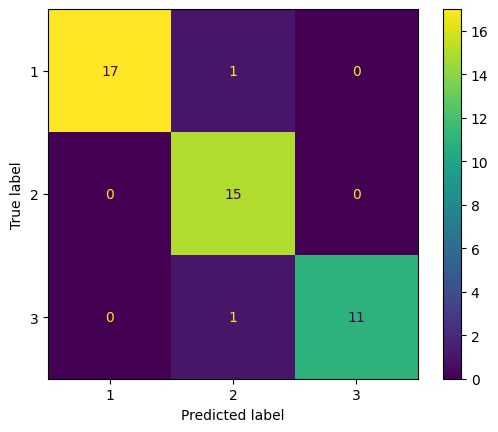

In [14]:
# import all the required packages for classification model evaluation
from sklearn.metrics import classification_report,confusion_matrix, ConfusionMatrixDisplay

# Construct and plot the confusion matrix for the fuly-grown tree (clf model)
mlp_cm_test = confusion_matrix(y_test, predictions, labels=mlp.classes_ )
disp = ConfusionMatrixDisplay(mlp_cm_test,display_labels=mlp.classes_   )
disp.plot()

In [15]:
# display the classification report
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           1       1.00      0.94      0.97        18
           2       0.88      1.00      0.94        15
           3       1.00      0.92      0.96        12

    accuracy                           0.96        45
   macro avg       0.96      0.95      0.96        45
weighted avg       0.96      0.96      0.96        45

